# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pydotplus

from sklearn.neighbors    import KNeighborsClassifier
from sklearn              import metrics as mt
from sklearn              import tree    as tr
from sklearn.ensemble     import RandomForestClassifier 
from IPython.display      import Image
from six                  import StringIO 
from sklearn.linear_model import LogisticRegression

# Carregando DataSet

In [2]:
df_x_train = pd.read_csv('dados_ensaio/ensaio_class/dados_train/x_train.csv')
df_y_train = pd.read_csv('dados_ensaio/ensaio_class/dados_train/y_train.csv')

df_x_val = pd.read_csv('dados_ensaio/ensaio_class/dados_val/x_val.csv')
df_y_val = pd.read_csv('dados_ensaio/ensaio_class/dados_val/y_val.csv')

df_x_test = pd.read_csv('dados_ensaio/ensaio_class/dados_test/x_test.csv')
df_y_test = pd.read_csv('dados_ensaio/ensaio_class/dados_test/y_test.csv')

# Observando os Dados

In [3]:
print(df_x_train.shape)
print(df_y_train.shape)

(72515, 25)
(72515, 1)


In [4]:
print(df_x_val.shape)
print(df_y_val.shape)

(31079, 25)
(31079, 1)


In [5]:
print(df_x_test.shape)
print(df_y_test.shape)

(25893, 25)
(25893, 1)


# Ensaios

Vamos medir a performance dos algortimos KNN, Decision Tree, Random Forest e Logistic Regression, para os dados de Treino, Validação e Teste.

As métricas de performance serão: Accuracy, Precision, Recall e F1-Score.

Serão então 3 tabelas, para cada conjunto de dados, medindo Algoritmo x Métrica (4 x 4)

In [6]:
#definindo x e y
x_train = df_x_train
y_train = df_y_train

x_val = df_x_val
y_val = df_y_val

x_test = df_x_test
y_test = df_y_test

# KNN

Parâmetros de Ensaio: n_neighbors

#### KNN - VAL

In [7]:
#achando o memlhor parâmetro
valores_vizinhos = np.arange(1, 10, 2) #[i for ir in range(1, 60)]
f1 = []

for i in valores_vizinhos:
    knn_classifier = KNeighborsClassifier(n_neighbors = i)
    knn_classifier.fit(x_train, y_train)

    y_pred = knn_classifier.predict(x_val)

    f1.append(mt.f1_score(y_val, y_pred))



/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversi

In [8]:
#definindo maior valor de k
melhor_indice = np.argmax(f1)
melhor_k = valores_vizinhos[melhor_indice]
melhor_acc = f1[melhor_indice]
print(f' o indice do melhor k = {melhor_indice} e o melhor k = {melhor_k} e o melhor valor de k = {melhor_acc}')

 o indice do melhor k = 0 e o melhor k = 1 e o melhor valor de k = 0.6332905120205542


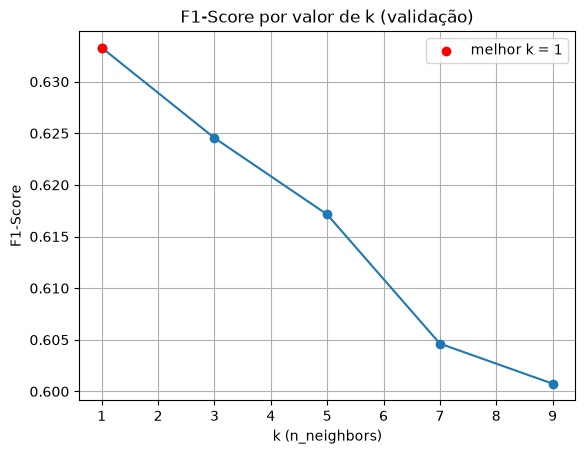

In [9]:
#plotando pra ver como ficou a relação dos números e de f1
plt.plot(valores_vizinhos, f1, marker='o')
plt.scatter(melhor_k, f1[melhor_indice], color='red', zorder=5, label=f'melhor k = {melhor_k}')

plt.title('F1-Score por valor de k (validação)')
plt.xlabel('k (n_neighbors)')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#treinando agora train com parâmetro
knn_classifier = KNeighborsClassifier(n_neighbors = 5)
knn_classifier.fit(x_train, y_train)

y_pred = knn_classifier.predict(x_val)

f1_val = mt.f1_score(y_val, y_pred)
acc_val = mt.accuracy_score(y_val, y_pred)
prec_val = mt.precision_score(y_val, y_pred)
rec_val = mt.recall_score(y_val, y_pred)

#tabela de resposta
tabela_result = pd.DataFrame({
    'k' : [melhor_k],
    'accuracy' : [acc_val],
    'precision' : [prec_val],
    'recall' : [rec_val],
    'f1-score' : [f1_val]
})

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [11]:
tabela_result

,k,accuracy,precision,recall,f1-score
0,1,0.675665,0.631775,0.603163,0.617138


#### KNN TRAIN

In [12]:
#treinando agora train com parâmetro
knn_classifier = KNeighborsClassifier(n_neighbors = 5)
knn_classifier.fit(x_train, y_train)

y_pred = knn_classifier.predict(x_train)

f1_train = mt.f1_score(y_train, y_pred)
acc_train = mt.accuracy_score(y_train, y_pred)
prec_train = mt.precision_score(y_train, y_pred)
rec_train = mt.recall_score(y_train, y_pred)

#tabela de resposta
tabela_result = pd.DataFrame({
    'k' : [melhor_k],
    'accuracy' : [acc_train],
    'precision' : [prec_train],
    'recall' : [rec_train],
    'f1-score' : [f1_train]
})

tabela_result

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,k,accuracy,precision,recall,f1-score
0,1,0.781562,0.755893,0.732563,0.744046


#### KNN TEST

In [13]:
#treinando agora test com parâmetro
knn_classifier = KNeighborsClassifier(n_neighbors = 5)
knn_classifier.fit(x_test, y_test)

y_pred = knn_classifier.predict(x_test)

f1_test = mt.f1_score(y_test, y_pred)
acc_test = mt.accuracy_score(y_test, y_pred)
prec_test = mt.precision_score(y_test, y_pred)
rec_test = mt.recall_score(y_test, y_pred)

#tabela de resposta
tabela_result = pd.DataFrame({
    'k' : [melhor_k],
    'accuracy' : [acc_test],
    'precision' : [prec_test],
    'recall' : [rec_test],
    'f1-score' : [f1_test]
})

tabela_result

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,k,accuracy,precision,recall,f1-score
0,1,0.759317,0.738811,0.698636,0.718162


### Decision Tree

Parâmetros de Ensaio: max_depth

#### DT - VAL

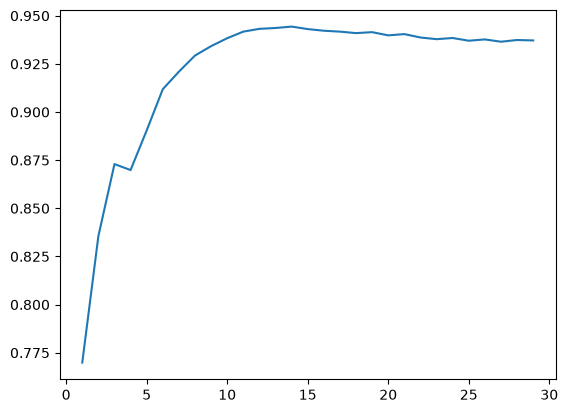

In [14]:
#achando melhor max_depth
numero_nos = np.arange(1, 30, 1)
f1_nos = []

for i in numero_nos:
    tree_clf = tr.DecisionTreeClassifier(max_depth=i)
    tree_clf.fit(x_train, y_train)

    y_pred = tree_clf.predict(x_val)

    f1_val = mt.f1_score(y_val, y_pred)

    f1_nos.append(f1_val)

plt.plot(numero_nos, f1_nos)
plt.show()

In [15]:
melhor_md = np.argmax(f1_nos) #numero 13
melhor_f1 = f1_nos[13] #0.944

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.380697 to fit
[1 0 1 ... 0 0 1]


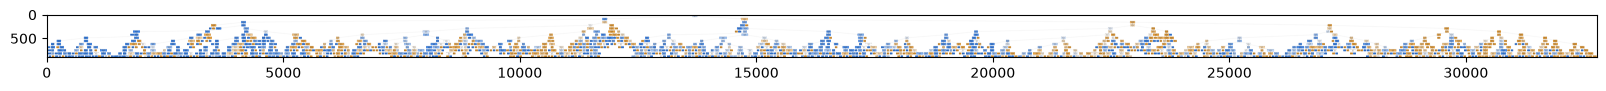

In [16]:
#Parametros e treinamento
tree_clf = tr.DecisionTreeClassifier(max_depth = 13)
tree_clf.fit(x_train,  y_train)

#exportando o esquema diagrama decition tree
dot_data = StringIO()
tr.export_graphviz(
    tree_clf,
    out_file = 'tree.dot',
    feature_names = x_val.columns.tolist(),
    class_names = [str(c) for c in tree_clf.classes_],
    rounded = True,
    filled = True
)

#convertendo .dot para .png para export esse diagrama
!dot -Tpng tree.dot -o tree.png

#carregando a imagem no jupyter notebook
img = cv2.imread('tree.png')
plt.figure(figsize=(20,20))
plt.imshow(img)

#prevendo
y_pred = tree_clf.predict(x_val)
print(y_pred)

In [17]:
acc_val = mt.accuracy_score(y_val, y_pred)
prec_val = mt.precision_score(y_val, y_pred)
rec_val = mt.recall_score(y_val, y_pred)
f1_val = mt.f1_score(y_val, y_pred)

tabela_tree = pd.DataFrame({
    'max_depth': [tree_clf.max_depth],
    'accuracy': [acc_val],
    'precision': [prec_val],
    'recall': [rec_val],
    'f1': [f1_val]
})

tabela_tree

,max_depth,accuracy,precision,recall,f1
0,13,0.952605,0.95626,0.933328,0.944655


#### DT - TRAIN

In [18]:
#Parametros e treinamento
tree_clf = tr.DecisionTreeClassifier(max_depth = 13)
tree_clf.fit(x_train,  y_train)

#prevendo
y_pred = tree_clf.predict(x_train)
print(y_pred)

acc_train = mt.accuracy_score(y_train, y_pred)
prec_train = mt.precision_score(y_train, y_pred)
rec_train = mt.recall_score(y_train, y_pred)
f1_train = mt.f1_score(y_train, y_pred)

tabela_tree = pd.DataFrame({
    'max_depth': [tree_clf.max_depth],
    'accuracy': [acc_train],
    'precision': [prec_train],
    'recall': [rec_train],
    'f1': [f1_train]
})

tabela_tree

[1 1 0 ... 1 0 0]


,max_depth,accuracy,precision,recall,f1
0,13,0.970847,0.977676,0.954531,0.965965


#### DT - TESTE

In [19]:
#Parametros e treinamento
tree_clf = tr.DecisionTreeClassifier(max_depth = 13)
tree_clf.fit(x_train,  y_train)

#prevendo
y_pred = tree_clf.predict(x_test)
print(y_pred)

acc_test = mt.accuracy_score(y_test, y_pred)
prec_test = mt.precision_score(y_test, y_pred)
rec_test = mt.recall_score(y_test, y_pred)
f1_test = mt.f1_score(y_test, y_pred)

tabela_tree = pd.DataFrame({
    'max_depth': [tree_clf.max_depth],
    'accuracy': [acc_test],
    'precision': [prec_test],
    'recall': [rec_test],
    'f1': [f1_test]
})

tabela_tree

[1 1 0 ... 0 1 0]


,max_depth,accuracy,precision,recall,f1
0,13,0.951609,0.953778,0.935064,0.944328


### Random Forest

Parâmetros de Ensaio: n_estimators, max_depth

In [20]:
#achando os melhores parâmetros em Random Forest:
n_estimators_range = np.arange(50, 501, 100)
max_depth_range = np.arange(2, 21, 4)

resultados = []

for i in n_estimators_range:
    for j in max_depth_range:
        rf_clf = RandomForestClassifier(n_estimators=i, max_depth=j, n_jobs=-1)
        rf_clf.fit(x_train, y_train)

        y_scores = rf_clf.predict(x_val)
        f1_val = mt.f1_score(y_val, y_scores)

        resultados.append({'n_estimators': i, 'max_depth': j, 'f1_val': f1_val})

tabela_rf = pd.DataFrame(resultados)
tabela_rf.sort_values(by = 'f1_val', ascending = False)

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: 

,n_estimators,max_depth,f1_val
9,150,18,0.958179
19,350,18,0.958128
24,450,18,0.957931
14,250,18,0.957820
4,50,18,0.956584
23,450,14,0.955520
13,250,14,0.955203
18,350,14,0.955186
3,50,14,0.954653
8,150,14,0.954421


#### Random Forest - VAL

In [21]:
#aplicando os melhores parâmetros em dados de val

rf_clf = RandomForestClassifier(n_estimators=250, max_depth=18, n_jobs=-1)
rf_clf.fit(x_train, y_train)

y_scores = rf_clf.predict(x_val)

acc_val = mt.accuracy_score(y_val, y_scores)
prec_val = mt.precision_score(y_val, y_scores)
rec_val = mt.recall_score(y_val, y_scores)
f1_val = mt.f1_score(y_val, y_scores)

tabela_val_result = pd.DataFrame({
    'accuracy': [acc_val],
    'precision': [prec_val],
    'recall': [rec_val],
    'f1': [f1_val]
})
tabela_val_result

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,accuracy,precision,recall,f1
0,0.964092,0.973114,0.943203,0.957925


#### Random Forest - TRAIN

In [22]:
#aplicando os melhores parâmetros em dados de train

rf_clf = RandomForestClassifier(n_estimators=250, max_depth=18, n_jobs=-1)
rf_clf.fit(x_train, y_train)

y_scores = rf_clf.predict(x_train)

acc_train = mt.accuracy_score(y_train, y_scores)
prec_train = mt.precision_score(y_train, y_scores)
rec_train = mt.recall_score(y_train, y_scores)
f1_train = mt.f1_score(y_train, y_scores)

tabela_train_result = pd.DataFrame({
    'accuracy': [acc_train],
    'precision': [prec_train],
    'recall': [rec_train],
    'f1': [f1_train]
})
tabela_train_result

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,accuracy,precision,recall,f1
0,0.992002,0.995471,0.986032,0.990729


#### Random Forest - TEST

In [23]:
#aplicando os melhores parâmetros em dados de test

rf_clf = RandomForestClassifier(n_estimators=250, max_depth=18, n_jobs=-1)
rf_clf.fit(x_train, y_train)

y_scores = rf_clf.predict(x_test)

acc_test = mt.accuracy_score(y_test, y_scores)
prec_test = mt.precision_score(y_test, y_scores)
rec_test = mt.recall_score(y_test, y_scores)
f1_test = mt.f1_score(y_test, y_scores)

tabela_test_result = pd.DataFrame({
    'accuracy': [acc_test],
    'precision': [prec_test],
    'recall': [rec_test],
    'f1': [f1_test]
})
tabela_test_result

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,accuracy,precision,recall,f1
0,0.963813,0.971599,0.945183,0.958209


### Logisct Regression

Parâmetros de Ensaio: c, solver, max_iter

### LR - Val

In [27]:
#achando os melhores parâmetros em Logistic Regression:
c_range = [0.01, 0.1, 1, 10, 100]
solver_range = ['liblinear', 'lbfgs']
max_iter_range = [100, 500, 1000]

resultados = []

for i in c_range:
    for j in solver_range:
        for k in max_iter_range:

            model_lr = LogisticRegression(C=i, solver=j, max_iter=k)
            model_lr.fit(x_train, y_train)

            y_pred = model_lr.predict(x_val)

            resultados.append({
                'C': i,
                'Solver': j,
                'Max_Iter': k,
                'Accuracy': mt.accuracy_score(y_val, y_pred),
                'Precision': mt.precision_score(y_val, y_pred),
                'Recall': mt.recall_score(y_val, y_pred),
                'F1': mt.f1_score(y_val, y_pred)
            })

tabela_result = pd.DataFrame(resultados)
tabela_result


/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWar

,C,Solver,Max_Iter,Accuracy,Precision,Recall,F1
0,0.01,liblinear,100,0.836159,0.794364,0.839186,0.816160
1,0.01,liblinear,500,0.836159,0.794364,0.839186,0.816160
2,0.01,liblinear,1000,0.836159,0.794364,0.839186,0.816160
3,0.01,lbfgs,100,0.858972,0.832236,0.844903,0.838522
4,0.01,lbfgs,500,0.871231,0.863919,0.834286,0.848844
5,0.01,lbfgs,1000,0.872068,0.866384,0.833321,0.849531
6,0.10,liblinear,100,0.794556,0.731322,0.831391,0.778152
7,0.10,liblinear,500,0.794556,0.731322,0.831391,0.778152
8,0.10,liblinear,1000,0.794556,0.731322,0.831391,0.778152
9,0.10,lbfgs,100,0.849770,0.837061,0.811270,0.823964


In [ ]:
#achando o melhor indice
melhor_indice = np.argmax(tabela_result['Accuracy'])
melhor_linha = tabela_result.iloc[melhor_indice]
melhor_linha

C                10.0
Solver          lbfgs
Max_Iter         1000
Accuracy     0.874159
Precision    0.869663
Recall       0.834732
F1           0.851839
Name: 23, dtype: object

In [ ]:
#usando os melhores parâmetros - val

model_lr = LogisticRegression(C=10, solver='lbfgs', max_iter=500)
model_lr.fit(x_train, y_train)

y_pred = model_lr.predict(x_val)

tabela_lr_val = pd.DataFrame({
    'Accuracy': [mt.accuracy_score(y_val, y_pred)],
    'Precision': [mt.precision_score(y_val, y_pred)],
    'Recall': [mt.recall_score(y_val, y_pred)],
    'F1': [mt.f1_score(y_val, y_pred)]
})

tabela_lr_val

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall,F1
0,0.872583,0.869282,0.830945,0.849681


### LR - TRAIN

In [43]:
#usando os melhores parâmetros - train

model_lr = LogisticRegression(C=10, solver='lbfgs', max_iter=500)
model_lr.fit(x_train, y_train)

y_pred = model_lr.predict(x_train)

tabela_lr_train = pd.DataFrame({
    'Accuracy': [mt.accuracy_score(y_train, y_pred)],
    'Precision': [mt.precision_score(y_train, y_pred)],
    'Recall': [mt.recall_score(y_train, y_pred)],
    'F1': [mt.f1_score(y_train, y_pred)]
})

tabela_lr_train

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall,F1
0,0.873861,0.870646,0.832665,0.851232


### LR - TEST

In [44]:
#usando os melhores parâmetros - train

model_lr = LogisticRegression(C=10, solver='lbfgs', max_iter=500)
model_lr.fit(x_train, y_train)

y_pred = model_lr.predict(x_test)

tabela_lr_test = pd.DataFrame({
    'Accuracy': [mt.accuracy_score(y_test, y_pred)],
    'Precision': [mt.precision_score(y_test, y_pred)],
    'Recall': [mt.recall_score(y_test, y_pred)],
    'F1': [mt.f1_score(y_test, y_pred)]
})

tabela_lr_test

/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/lucas/.pyenv/versions/aulas_ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,Precision,Recall,F1
0,0.86954,0.867624,0.8293,0.84803
